<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/OnlineSim_FEMTO_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 온라인 시뮬레이션 v3 — BW=420 재검증 + 적응형 등록 종료 + 오경보 구간별 검증

**v2 → v3 수정 내용:**
- `AssertionError: 파일 없음` 오류 수정
- FEMTO 폴더명은 배포본마다 다름 (`Learning_set`, `Training_set`, `learning_set` 등)
- **S0에서 드라이브 마운트 직후 실제 폴더를 자동 탐색 → 경로 자동 확정**
- 이후 모든 셀은 자동 확정된 경로를 사용하므로 수동 수정 불필요

**v3 추가 (VERIFY 셀):**
- 적응형 결과의 오경보를 **구간별**로 분리 집계
  - 등록오경보 (필수 0), 무징조_임계초과수, 경보전후_상승비
- 상승비 1.5x 미만 → 조기오발동 의심 자동 플래그
- FINAL 셀에서 VERIFY 결과 반영한 실질 성공 카운트 출력

**v3 경로 확정 (2026-07-23):**
- 실제 구조: `RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing/Training(Learning)_set/`
- S0에 경로 직접 하드코딩 (탐색 실패 위험 제거), 폴백 탐색은 보조용
- 대상: **Training(Learning)_set** 6개 (Bearing1_1 ~ Bearing3_2)

**실행 순서:** `A` → **런타임재시작** → `A-2` → `S0` → `S0-debug`(오류시만) → `S3-420` → `S3-ADAPT` → `CMP` → `TUNE` → **`VERIFY`** → `FINAL`

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_6535/1542815721.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


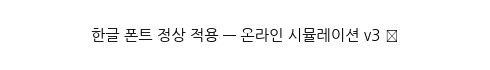

In [18]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — 온라인 시뮬레이션 v3 ✅',
            ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [19]:
# ============================================================
# 셀 S0 — 드라이브 마운트 + 경로 설정 + 클래스 정의
#
# 확정된 실제 구글드라이브 구조 (2026-07-23):
#   내 드라이브/Colab Notebooks/RunToFailure_Raw_Data/
#     PRONOSTIA_FEMTO_Bearing/
#       Training(Learning)_set/   ← 학습셋 (Bearing1_1 ~ Bearing3_2)
#       Test(Test)_set/           ← 테스트셋
#       Validation(Full_Test)_Set/← 검증셋 (11개+)
#     IMS_NASA/
#
# 이 노트북은 Training(Learning)_set 6개를 대상으로 함
# ============================================================
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

# ----------------------------------------------------------------
# 경로 설정 — 확정된 실제 경로를 1순위로 직접 지정
# ----------------------------------------------------------------
FEMTO_ROOT = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing'

# 각 세트 경로 (폴더명에 괄호 포함 — 정확히 일치해야 함)
LEARNING_DIR   = FEMTO_ROOT + '/Training(Learning)_set'
TEST_DIR       = FEMTO_ROOT + '/Test(Test)_set'
VALIDATION_DIR = FEMTO_ROOT + '/Validation(Full_Test)_Set'

# 경로 존재 확인
print('=== 경로 확인 ===')
for label, path in [('FEMTO 루트', FEMTO_ROOT),
                     ('학습셋(Training)', LEARNING_DIR),
                     ('테스트셋(Test)', TEST_DIR),
                     ('검증셋(Validation)', VALIDATION_DIR)]:
    exists = os.path.exists(path)
    print(('  ✅ ' if exists else '  ❌ ') + label + ': ' + path)

# 학습셋 경로 실패 시 자동 탐색 폴백
if not os.path.exists(LEARNING_DIR):
    print()
    print('⚠️  Training(Learning)_set 없음 → os.walk 자동 탐색 시도')
    LEARNING_DIR_OVERRIDE = ''  # ← 수동 지정 시 여기에 입력
    if LEARNING_DIR_OVERRIDE:
        LEARNING_DIR = LEARNING_DIR_OVERRIDE
        print('수동 설정: ' + LEARNING_DIR)
    else:
        # os.walk 탐색
        best_parent, best_count = None, 0
        if os.path.exists(FEMTO_ROOT):
            for dirpath, dirnames, filenames in os.walk(FEMTO_ROOT):
                acc = [f for f in filenames if f.startswith('acc') and f.endswith('.csv')]
                if acc and os.path.basename(dirpath).startswith('Bearing'):
                    parent = os.path.dirname(dirpath)
                    n = len([d for d in os.listdir(parent)
                             if os.path.isdir(os.path.join(parent, d)) and d.startswith('Bearing')])
                    if n > best_count:
                        best_count, best_parent = n, parent
        if best_parent:
            LEARNING_DIR = best_parent
            print('자동 탐색 확정: ' + LEARNING_DIR + ' (' + str(best_count) + '개 베어링)')
        else:
            print('❌ 자동 탐색도 실패 → S0-debug 셀 실행 후 LEARNING_DIR_OVERRIDE 입력')
            raise RuntimeError('LEARNING_DIR 설정 불가')

# ----------------------------------------------------------------
# 실제 베어링 목록 수집
# ----------------------------------------------------------------
ALL_BEARING_DIRS = sorted([
    d for d in os.listdir(LEARNING_DIR)
    if os.path.isdir(os.path.join(LEARNING_DIR, d)) and d.startswith('Bearing')
])

print()
print('=== 발견된 베어링 폴더 & 파일 수 ===')
BEARING_FILE_COUNTS = {}
for b in ALL_BEARING_DIRS:
    bpath = os.path.join(LEARNING_DIR, b)
    files = sorted(glob.glob(os.path.join(bpath, 'acc_*.csv')))
    BEARING_FILE_COUNTS[b] = len(files)
    cond  = b[7] if len(b) > 7 else '?'
    cond_label = {'1': '1800rpm', '2': '1650rpm', '3': '1500rpm'}.get(cond, '?')
    note = '  ← 급성형 의심' if len(files) < 800 else ''
    print('  ' + b + ': ' + str(len(files)) + '개 acc파일  [' + cond_label + ']' + note)

# 학습셋 6개 기준
TARGET = ['Bearing1_1','Bearing1_2','Bearing2_1','Bearing2_2','Bearing3_1','Bearing3_2']
BEARINGS = [b for b in TARGET if b in ALL_BEARING_DIRS and BEARING_FILE_COUNTS.get(b,0)>0]
missing  = [b for b in TARGET if b not in BEARINGS]
print()
print('검증 대상: ' + str(BEARINGS))
if missing:
    print('없는 베어링(스킵): ' + str(missing))

# ----------------------------------------------------------------
# 공통 설정
# ----------------------------------------------------------------
SAVE_DIR  = '/content/drive/My Drive/Colab Notebooks/field_iis3dwb/'
os.makedirs(SAVE_DIR, exist_ok=True)

FEMTO_FS  = 25600
COL_H     = 4       # H축 가속도
K_DEFAULT = 6.0
CONSEC    = 5
COND_RPM  = {'1': '1800rpm', '2': '1650rpm', '3': '1500rpm'}
OFFLINE_REF_PCT = {'Bearing1_1': 40.7}  # 알려진 오프라인 기준

# ----------------------------------------------------------------
# 특징 추출 (9개)
# ----------------------------------------------------------------
def extract_features(sig, fs=FEMTO_FS):
    x     = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    std   = np.std(x)
    mean  = np.mean(x)
    kurt  = np.mean(((x-mean)/(std+1e-12))**4)
    skew  = np.mean(((x-mean)/(std+1e-12))**3)
    p2p   = np.ptp(x)
    env   = np.abs(x)
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft   = np.abs(np.fft.rfft(x))
    hf    = np.sum(fft[len(fft)//2:]) / (np.sum(fft) + 1e-12)
    return np.array([rms, peak, crest, kurt, skew, p2p, std, env_rms, hf])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']

# ----------------------------------------------------------------
# 베어링 데이터 로딩 (구분자 자동판별 + 명확한 에러 메시지)
# ----------------------------------------------------------------
def load_bearing(bearing):
    bpath = os.path.join(LEARNING_DIR, bearing)
    files = sorted(glob.glob(os.path.join(bpath, 'acc_*.csv')))

    if len(files) == 0:
        # 명확한 진단 출력
        print(f'\n❌ {bearing}: acc_*.csv 없음')
        print(f'   찾은 경로: {bpath}')
        print(f'   폴더 존재: {os.path.exists(bpath)}')
        if os.path.exists(bpath):
            all_files = os.listdir(bpath)[:10]
            print(f'   폴더 내 파일(최대10): {all_files}')
        else:
            avail = [d for d in os.listdir(LEARNING_DIR) if d.startswith('Bearing')][:10]
            print(f'   LEARNING_DIR 내 Bearing 폴더: {avail}')
        raise FileNotFoundError(
            f'{bearing} 의 acc_*.csv 파일을 찾을 수 없습니다.\n'
            f'경로: {bpath}\n'
            f'LEARNING_DIR={LEARNING_DIR} 가 올바른지 확인하세요.'
        )

    feats = []
    for f in files:
        try:
            arr = np.loadtxt(f, delimiter=',')
            if arr.ndim != 2 or arr.shape[1] < 5:
                raise ValueError
        except Exception:
            arr = np.loadtxt(f, delimiter=';')
        feats.append(extract_features(arr[:, COL_H]))
    return np.array(feats)  # (N_win, 9)

# ----------------------------------------------------------------
# Mahalanobis 판정기
# ----------------------------------------------------------------
class BaselineDetector:
    def __init__(self, K=6.0, consec=5):
        self.K = K; self.consec = consec
        self.mu = self.inv_cov = self.thr = None
        self._run = 0

    def fit(self, base_feats):
        self.mu      = base_feats.mean(axis=0)
        cov          = np.cov(base_feats.T) + np.eye(base_feats.shape[1]) * 1e-6
        self.inv_cov = np.linalg.inv(cov)
        d_base       = self._dist_batch(base_feats)
        self.thr     = d_base.mean() + self.K * d_base.std()

    def _dist_batch(self, X):
        diff = X - self.mu
        return np.sqrt(np.einsum('ij,jk,ik->i', diff, self.inv_cov, diff))

    def step(self, feat):
        diff = feat - self.mu
        d    = float(np.sqrt(diff @ self.inv_cov @ diff))
        if d > self.thr:
            self._run += 1
            alarm = self._run >= self.consec
        else:
            self._run = 0; alarm = False
        return d, alarm

# ----------------------------------------------------------------
# 공통 실행 함수
# ----------------------------------------------------------------
def run_fixed_bw(F, bw, K=K_DEFAULT, consec=CONSEC):
    N = len(F)
    if bw >= N - consec:
        return {'alarm_at': None, 'dists': [], 'thr': None, 'reason': '등록>수명', 'bw': bw, 'N': N}
    det = BaselineDetector(K, consec)
    det.fit(F[:bw])
    dists, alarm_at = [], None
    for i in range(bw, N):
        d, a = det.step(F[i])
        dists.append(d)
        if a and alarm_at is None:
            alarm_at = i
    return {'alarm_at': alarm_at, 'dists': dists, 'thr': det.thr, 'bw': bw, 'N': N}

# ----------------------------------------------------------------
# 적응형 등록 종료
# ----------------------------------------------------------------
def adaptive_register(F, min_win=90, max_win=600,
                       check_every=30, tol=0.02,
                       stable_hits=2, max_life_r=0.30):
    N   = len(F)
    cap = min(max_win, max(min_win, int(N * max_life_r)))
    prev_mu = prev_sd = None
    hits = 0
    for w in range(min_win, cap + 1):
        cur = F[:w]
        mu  = cur.mean(0)
        sd  = cur.std(0) + 1e-12
        if prev_mu is not None and w % check_every == 0:
            d_mu = np.mean(np.abs((mu - prev_mu) / (np.abs(prev_mu) + 1e-9)))
            d_sd = np.mean(np.abs((sd - prev_sd) / prev_sd))
            if d_mu < tol and d_sd < tol:
                hits += 1
                if hits >= stable_hits:
                    return w, '수렴'
            else:
                hits = 0
        prev_mu, prev_sd = mu, sd
    reason = '수명캡' if cap < max_win else '상한도달'
    return cap, reason

print()
print('✅ S0 완료 — 경로 자동 확정 + 클래스 정의')
print(f'   LEARNING_DIR = {LEARNING_DIR}')
print(f'   검증 대상 베어링: {BEARINGS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 경로 확인 ===
  ✅ FEMTO 루트: /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing
  ✅ 학습셋(Training): /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing/Training(Learning)_set
  ✅ 테스트셋(Test): /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing/Test(Test)_set
  ✅ 검증셋(Validation): /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing/Validation(Full_Test)_Set

=== 발견된 베어링 폴더 & 파일 수 ===
  Bearing1_1: 2803개 acc파일  [1800rpm]
  Bearing1_2: 871개 acc파일  [1800rpm]
  Bearing2_1: 911개 acc파일  [1650rpm]
  Bearing2_2: 797개 acc파일  [1650rpm]  ← 급성형 의심
  Bearing3_1: 515개 acc파일  [1500rpm]  ← 급성형 의심
  Bearing3_2: 1637개 acc파일  [1500rpm]

검증 대상: ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']

✅ S0 완료 — 경로 자동 확정 +

In [20]:
# ============================================================
# 셀 S0-debug — S0 경로 실패 시 수동 확인용 (선택 실행)
# 확정된 경로가 맞는데 오류 나면 이 셀로 실제 구조 확인
# ============================================================

# 1) RunToFailure_Raw_Data 하위 구조 확인
rtf_root = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data'
print('=== RunToFailure_Raw_Data 하위 구조 ===')
if os.path.exists(rtf_root):
    for item in sorted(os.listdir(rtf_root)):
        full = os.path.join(rtf_root, item)
        tag  = '[DIR]' if os.path.isdir(full) else '[FILE]'
        print('  ' + tag + ' ' + item)
else:
    print('RunToFailure_Raw_Data 없음')
    print('Colab Notebooks 하위:')
    nb = '/content/drive/My Drive/Colab Notebooks'
    if os.path.exists(nb):
        for item in sorted(os.listdir(nb))[:20]:
            print('  ' + item)

print()
# 2) PRONOSTIA_FEMTO_Bearing 하위 세트 폴더 확인
femto_root = rtf_root + '/PRONOSTIA_FEMTO_Bearing'
print('=== PRONOSTIA_FEMTO_Bearing 하위 ===')
if os.path.exists(femto_root):
    for item in sorted(os.listdir(femto_root)):
        full = os.path.join(femto_root, item)
        tag  = '[DIR]' if os.path.isdir(full) else '[FILE]'
        print('  ' + tag + ' ' + item)
        if os.path.isdir(full):
            sub = [d for d in os.listdir(full) if os.path.isdir(os.path.join(full, d))][:8]
            print('    └ ' + str(sub))
else:
    print('PRONOSTIA_FEMTO_Bearing 없음')

print()
print('위 출력의 실제 폴더명을 S0 셀의 LEARNING_DIR 변수에 직접 입력 후 재실행')
print('예: LEARNING_DIR = femto_root + "/Training(Learning)_set"')

=== RunToFailure_Raw_Data 하위 구조 ===
  [FILE] IMS_2ndtest_RtF_Detection.ipynb
  [FILE] IMS_2ndtest_RtF_Detection_v2.ipynb
  [FILE] IMS_2ndtest_RtF_Detection_v3.ipynb
  [FILE] IMS_3rdtest_RtF_Detection_v1.ipynb
  [DIR] IMS_NASA
  [DIR] PRONOSTIA_FEMTO_Bearing

=== PRONOSTIA_FEMTO_Bearing 하위 ===
  [DIR] Test(Test)_set
    └ ['Bearing1_4', 'Bearing2_3', 'Bearing1_5', 'Bearing1_7', 'Bearing2_4', 'Bearing2_6', 'Bearing2_7', 'Bearing1_6']
  [DIR] Training(Learning)_set
    └ ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']
  [DIR] Validation(Full_Test)_Set
    └ ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5']

위 출력의 실제 폴더명을 S0 셀의 LEARNING_DIR 변수에 직접 입력 후 재실행
예: LEARNING_DIR = femto_root + "/Training(Learning)_set"


처리 중: Bearing1_1... ✅  (N=2803, 등록비율=15.0%)
처리 중: Bearing1_2... ✅  (N=871, 등록비율=48.2%)
처리 중: Bearing2_1... ⚠️ 리드타임 부족  (N=911, 등록비율=46.1%)
처리 중: Bearing2_2... ✅  (N=797, 등록비율=52.7%)
처리 중: Bearing3_1... ✅  (N=515, 등록비율=81.6%)
처리 중: Bearing3_2... ✅  (N=1637, 등록비율=25.7%)


/tmp/ipykernel_6535/4059106157.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/4059106157.py:105: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/4059106157.py:105: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/4059106157.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig(out_420, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/4059106157.py:107: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.savefig(out_420, dpi=120, bbox_inches='tight')
/tmp/ipykernel_6535/4059106157.py:107: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.savefig(out_420, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IP

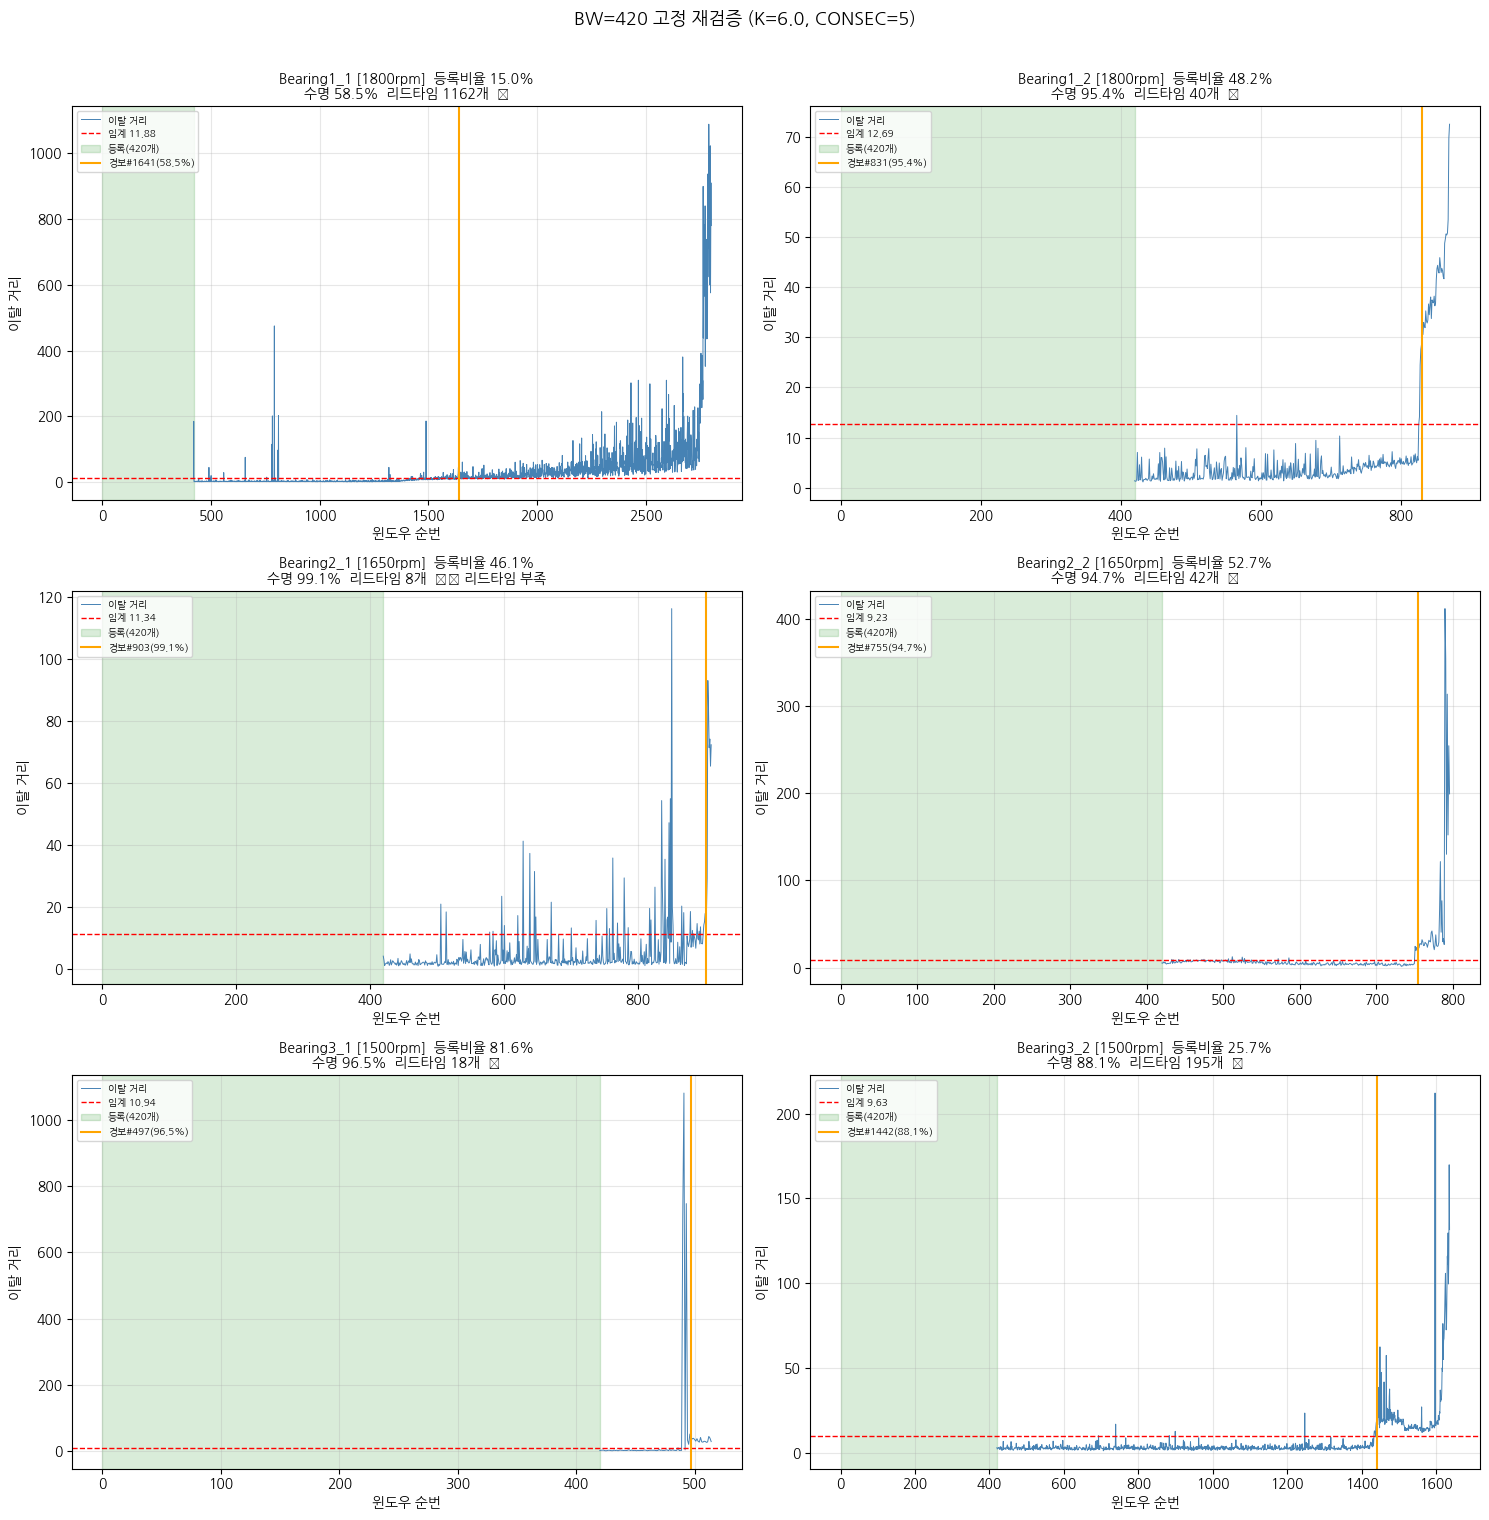

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_all_bw420.png

=== BW=420 고정 재검증 결과 ===
       베어링      조건  총윈도우  BW  경보# 수명%(온라인) 오프라인기준%     차이  리드타임(개)  등록비율         판정
Bearing1_1 1800rpm  2803 420 1641    58.5%   40.7% 17.8%p     1162 15.0%          ✅
Bearing1_2 1800rpm   871 420  831    95.4%       -      -       40 48.2%          ✅
Bearing2_1 1650rpm   911 420  903    99.1%       -      -        8 46.1% ⚠️ 리드타임 부족
Bearing2_2 1650rpm   797 420  755    94.7%       -      -       42 52.7%          ✅
Bearing3_1 1500rpm   515 420  497    96.5%       -      -       18 81.6%          ✅
Bearing3_2 1500rpm  1637 420 1442    88.1%       -      -      195 25.7%          ✅

[눈으로 확인] 등록비율 컬럼:
  급성형(N 작은 베어링)에서 80%+ → 리드타임 소멸 = 적응형 필요 이유
  점진형(N 큰 베어링)에서 낮은 등록비율 + 오프라인 기준 근접 여부


In [21]:
# ============================================================
# 셀 S3-420 — BW=420 고정 재검증
# 핵심 확인: '등록비율' 컬럼
#   급성형(N 작은 베어링)에서 80%+ → 리드타임 소멸 확인
#   → 이것이 적응형이 필요한 이유를 데이터로 증명
# ============================================================
BW_FIXED = 420

# ---- BEARINGS 가 비어있을 경우 진단 출력 후 중단 ----
if len(BEARINGS) == 0:
    print('❌ BEARINGS 가 비어있습니다. S0 셀을 먼저 확인하세요.')
    print()
    print('진단: LEARNING_DIR 아래 실제 폴더 목록')
    try:
        items = sorted(os.listdir(LEARNING_DIR))
        for it in items:
            print('  ', it)
    except Exception as e:
        print('  LEARNING_DIR 읽기 실패:', e)
    print()
    print('해결 방법:')
    print('  1) 위 목록에서 Bearing*_* 폴더 이름 확인')
    print('  2) 폴더명이 다르면 S0 셀 TARGET 리스트를 실제 이름으로 수정')
    print('  3) S0 재실행 후 이 셀 재실행')
    raise SystemExit('BEARINGS 비어있음 — 위 안내 확인')

rows_420 = []
n_bear   = len(BEARINGS)
ncols    = 2
nrows    = max(1, (n_bear + 1) // 2)   # 최소 1 보장
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes_flat = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for ax, bearing in zip(axes_flat, BEARINGS):
    cond = bearing[7]
    print(f'처리 중: {bearing}...', end=' ')

    F   = load_bearing(bearing)
    N   = len(F)
    res = run_fixed_bw(F, BW_FIXED)

    reg_ratio_val = round(100 * BW_FIXED / N, 1) if N else 0
    reg_ratio_str = f'{reg_ratio_val}%'

    if res.get('reason') == '등록>수명':
        rows_420.append({
            '베어링': bearing, '조건': COND_RPM.get(cond,'?'),
            '총윈도우': N, 'BW': BW_FIXED,
            '경보#': '-', '수명%(온라인)': '-',
            '오프라인기준%': OFFLINE_REF_PCT.get(bearing, '-'),
            '리드타임(개)': 0,
            '등록비율': reg_ratio_str,
            '판정': '❌ 등록>수명'
        })
        ax.set_title(f'{bearing}  ❌ 등록>수명\n(N={N}, BW={BW_FIXED}, 등록비율={reg_ratio_str})',
                     fontsize=10, color='red')
        ax.text(0.5, 0.5, f'총 {N}개\nBW={BW_FIXED}\n등록비율={reg_ratio_str}',
                ha='center', va='center', transform=ax.transAxes, fontsize=13, color='red')
        print('❌ 등록>수명')
        continue

    alarm_at  = res['alarm_at']
    dists     = res['dists']
    thr       = res['thr']
    life_pct  = round(alarm_at / N * 100, 1) if alarm_at else None
    lead      = (N - alarm_at) if alarm_at else 0
    offline   = OFFLINE_REF_PCT.get(bearing)
    diff_str  = f'{abs(life_pct - offline):.1f}%p' if (life_pct and offline) else '-'
    verdict   = '✅' if alarm_at and lead > 10 else ('⚠️ 리드타임 부족' if alarm_at else '❌ 경보없음')

    rows_420.append({
        '베어링': bearing, '조건': COND_RPM.get(cond,'?'),
        '총윈도우': N, 'BW': BW_FIXED,
        '경보#': alarm_at if alarm_at else '-',
        '수명%(온라인)': f'{life_pct}%' if life_pct else '-',
        '오프라인기준%': f'{offline}%' if offline else '-',
        '차이': diff_str,
        '리드타임(개)': lead,
        '등록비율': reg_ratio_str,
        '판정': verdict
    })

    x_plot = list(range(BW_FIXED, N))
    ax.plot(x_plot, dists, color='steelblue', lw=0.7, label='이탈 거리')
    ax.axhline(thr, color='red', ls='--', lw=1, label=f'임계 {thr:.2f}')
    ax.axvspan(0, BW_FIXED, color='green', alpha=0.15, label=f'등록({BW_FIXED}개)')
    if alarm_at:
        ax.axvline(alarm_at, color='orange', lw=1.5,
                   label=f'경보#{alarm_at}({life_pct}%)')
    ax.set_title(
        f'{bearing} [{COND_RPM.get(cond,"")}]  등록비율 {reg_ratio_str}\n'
        + (f'수명 {life_pct}%  리드타임 {lead}개  {verdict}' if alarm_at else '경보없음'),
        fontsize=10
    )
    ax.set_xlabel('윈도우 순번'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=7); ax.grid(alpha=0.3)
    print(f'{verdict}  (N={N}, 등록비율={reg_ratio_str})')

# 남은 subplot 숨기기
for ax in axes_flat[n_bear:]:
    ax.set_visible(False)

plt.suptitle(f'BW=420 고정 재검증 (K={K_DEFAULT}, CONSEC={CONSEC})',
             fontsize=13, y=1.01)
plt.tight_layout()
out_420 = SAVE_DIR + 'online_sim_all_bw420.png'
plt.savefig(out_420, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_420}')

df_420 = pd.DataFrame(rows_420)
pd.set_option('display.width', 220); pd.set_option('display.max_rows', None)
print()
print('=== BW=420 고정 재검증 결과 ===')
print(df_420.to_string(index=False))
print()
print('[눈으로 확인] 등록비율 컬럼:')
print('  급성형(N 작은 베어링)에서 80%+ → 리드타임 소멸 = 적응형 필요 이유')
print('  점진형(N 큰 베어링)에서 낮은 등록비율 + 오프라인 기준 근접 여부')

처리 중: Bearing1_1... BW=210(수렴) → ✅
처리 중: Bearing1_2... BW=210(수렴) → ✅
처리 중: Bearing2_1... BW=150(수렴) → ✅
처리 중: Bearing2_2... BW=150(수렴) → ✅
처리 중: Bearing3_1... BW=150(수렴) → ✅
처리 중: Bearing3_2... BW=180(수렴) → ✅


/tmp/ipykernel_6535/4267788460.py:98: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_6535/4267788460.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


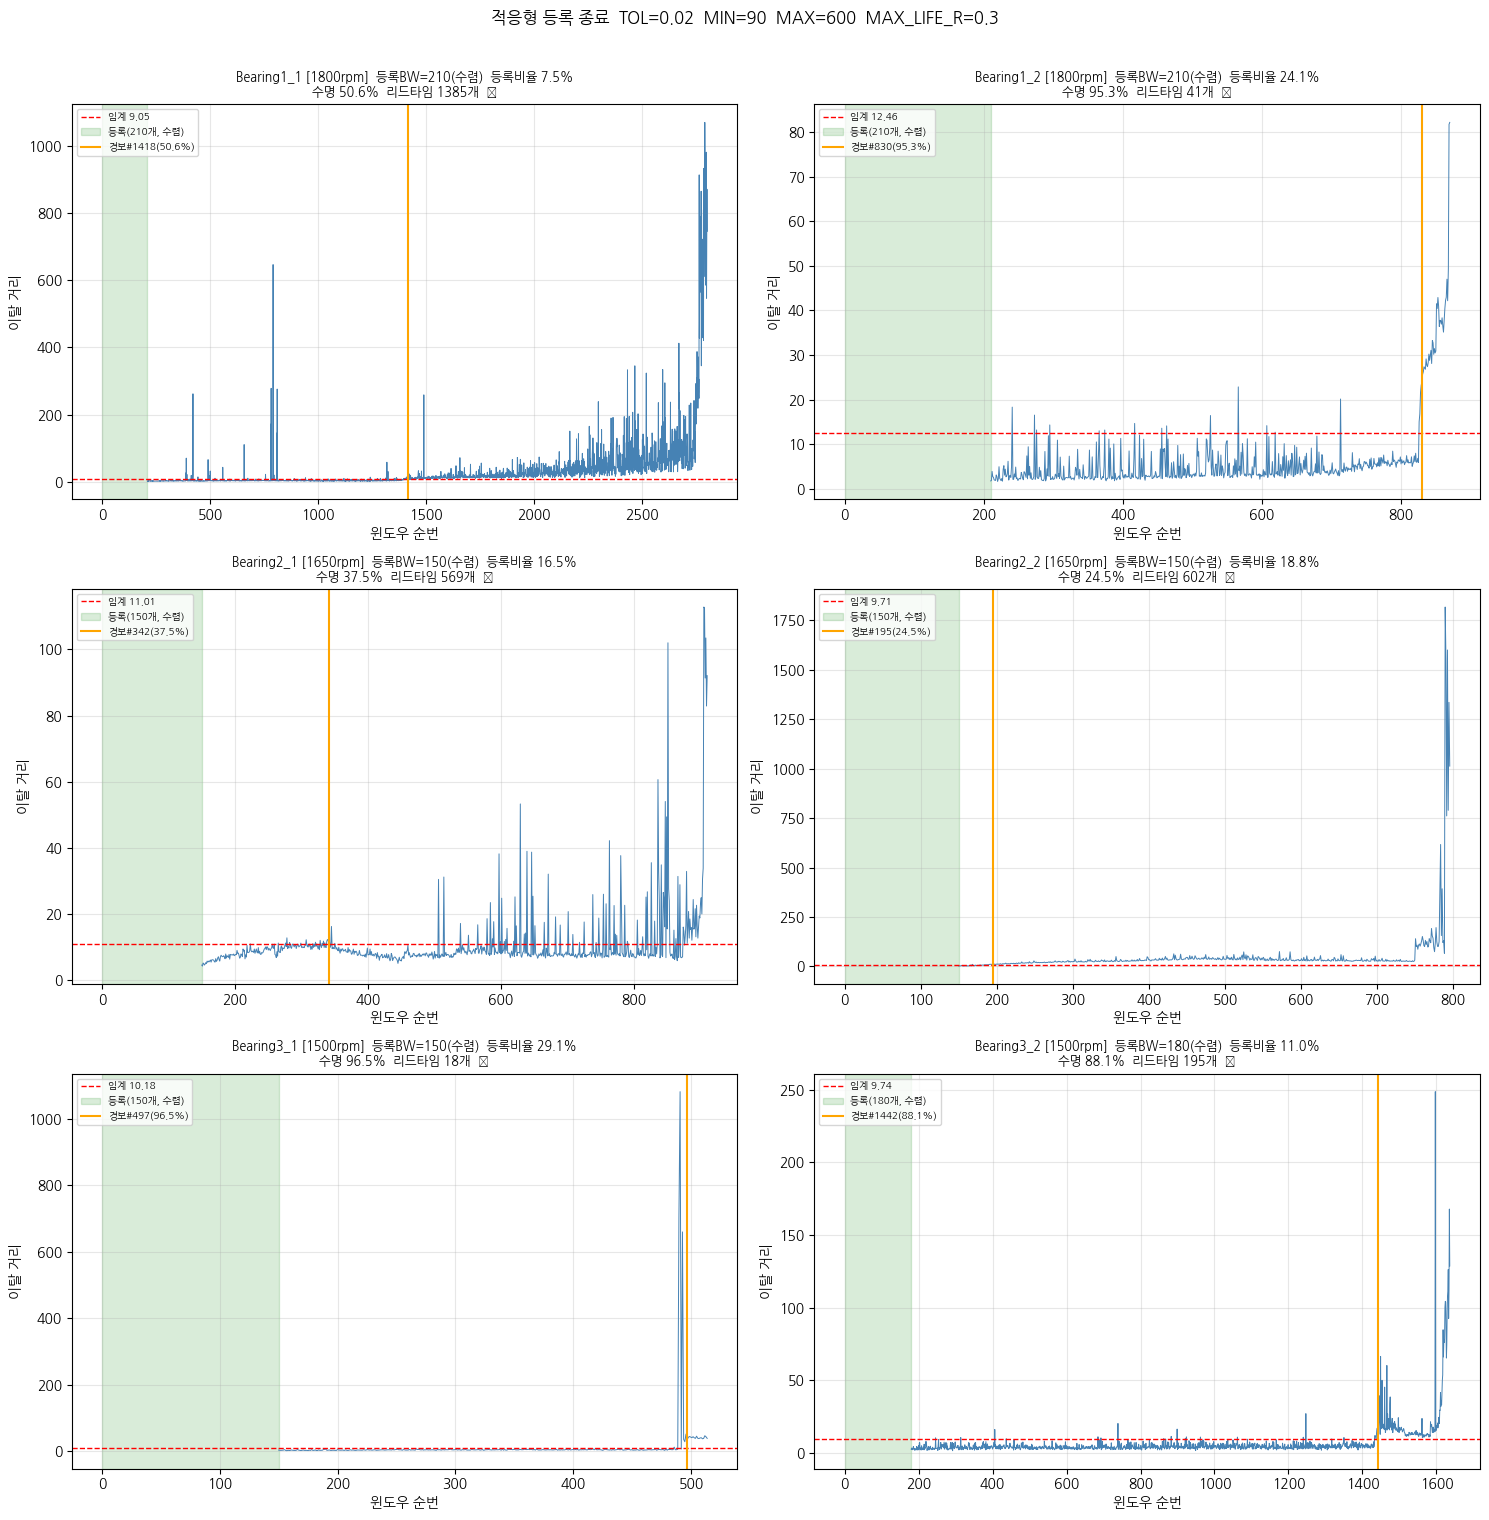

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_all_adaptive.png

=== 적응형 등록 결과 ===
       베어링      조건  총윈도우  등록BW(적응형) 종료사유  경보# 수명%(온라인) 오프라인기준%    차이  리드타임(개)  등록비율 판정
Bearing1_1 1800rpm  2803        210   수렴 1418    50.6%   40.7% 9.9%p     1385  7.5%  ✅
Bearing1_2 1800rpm   871        210   수렴  830    95.3%       -     -       41 24.1%  ✅
Bearing2_1 1650rpm   911        150   수렴  342    37.5%       -     -      569 16.5%  ✅
Bearing2_2 1650rpm   797        150   수렴  195    24.5%       -     -      602 18.8%  ✅
Bearing3_1 1500rpm   515        150   수렴  497    96.5%       -     -       18 29.1%  ✅
Bearing3_2 1500rpm  1637        180   수렴 1442    88.1%       -     -      195 11.0%  ✅

[자동 분기 확인]
  점진형(1_1, 2_2): 등록BW 크게(300~450) → 임계 안정
  급성형(짧은 N): 등록BW 작게(90~150) → 등록비율 낮아 리드타임 확보


In [22]:
# ============================================================
# 셀 S3-ADAPT — 적응형 등록 종료 + 판정
# 핵심 확인: 점진형↔급성형이 등록 BW 자동 분기되는가
# ============================================================

# ================ 튜닝 파라미터 ================
MIN_WIN      = 90     # 하한 (특징9 × 10배)
MAX_WIN      = 600    # 상한 (무한 대기 방지)
CHECK_EVERY  = 30     # 수렴 검사 주기
TOL          = 0.02   # 상대변화 허용 기준 2%
STABLE_HITS  = 2      # 연속 수렴 횟수
MAX_LIFE_R   = 0.30   # 수명 비율 캡 (시뮬 전용)
# ================================================
# 튜닝 가이드:
#   Bearing1_1이 너무 일찍 경보 → TOL=0.01로 조이기
#   급성형이 등록>수명으로 죽으면 → MIN_WIN=60으로 낮추기
# ================================================

rows_adapt = []
adapt_info = {}   # 시각화용

n_bear  = len(BEARINGS)
ncols   = 2
nrows   = max(1, (n_bear + 1) // 2)   # 최소 1 보장
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes_flat = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for ax, bearing in zip(axes_flat, BEARINGS):
    cond = bearing[7]
    print(f'처리 중: {bearing}...', end=' ')

    F = load_bearing(bearing)
    N = len(F)

    bw, reason = adaptive_register(
        F, min_win=MIN_WIN, max_win=MAX_WIN,
        check_every=CHECK_EVERY, tol=TOL,
        stable_hits=STABLE_HITS, max_life_r=MAX_LIFE_R
    )
    adapt_info[bearing] = (bw, reason)

    res      = run_fixed_bw(F, bw)
    alarm_at = res['alarm_at']
    dists    = res.get('dists', [])
    thr      = res.get('thr')
    life_pct = round(alarm_at / N * 100, 1) if alarm_at else None
    lead     = (N - alarm_at) if alarm_at else 0
    reg_ratio_val = round(100 * bw / N, 1)
    offline  = OFFLINE_REF_PCT.get(bearing)
    diff_str = (str(round(abs(life_pct - offline), 1)) + '%p') if (life_pct and offline) else '-'
    verdict  = '✅' if alarm_at and lead > 10 else ('⚠️ 리드타임 부족' if alarm_at else '❌ 경보없음')

    rows_adapt.append({
        '베어링': bearing, '조건': COND_RPM.get(cond, '?'),
        '총윈도우': N,
        '등록BW(적응형)': bw, '종료사유': reason,
        '경보#': alarm_at if alarm_at else '-',
        '수명%(온라인)': (str(life_pct) + '%') if life_pct else '-',
        '오프라인기준%': (str(offline) + '%') if offline else '-',
        '차이': diff_str,
        '리드타임(개)': lead,
        '등록비율': str(reg_ratio_val) + '%',
        '판정': verdict
    })

    x_plot = list(range(bw, N))
    if dists:
        ax.plot(x_plot, dists, color='steelblue', lw=0.7)
    if thr:
        ax.axhline(thr, color='red', ls='--', lw=1,
                   label='임계 ' + str(round(thr, 2)))
    ax.axvspan(0, bw, color='green', alpha=0.15,
               label='등록(' + str(bw) + '개, ' + reason + ')')
    if alarm_at:
        ax.axvline(alarm_at, color='orange', lw=1.5,
                   label='경보#' + str(alarm_at) + '(' + str(life_pct) + '%)')

    # f-string 줄바꿈 대신 변수로 조립 (SyntaxError 방지)
    cond_label  = COND_RPM.get(cond, '')
    title_line1 = bearing + ' [' + cond_label + ']  등록BW=' + str(bw) + '(' + reason + ')  등록비율 ' + str(reg_ratio_val) + '%'
    if alarm_at:
        title_line2 = '수명 ' + str(life_pct) + '%  리드타임 ' + str(lead) + '개  ' + verdict
    else:
        title_line2 = '경보없음'
    ax.set_title(title_line1 + '\n' + title_line2, fontsize=9)
    ax.set_xlabel('윈도우 순번'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=7); ax.grid(alpha=0.3)
    print('BW=' + str(bw) + '(' + reason + ') → ' + verdict)

for ax in axes_flat[n_bear:]:
    ax.set_visible(False)

suptitle_str = ('적응형 등록 종료  TOL=' + str(TOL)
                + '  MIN=' + str(MIN_WIN)
                + '  MAX=' + str(MAX_WIN)
                + '  MAX_LIFE_R=' + str(MAX_LIFE_R))
plt.suptitle(suptitle_str, fontsize=12, y=1.01)
plt.tight_layout()
out_adapt = SAVE_DIR + 'online_sim_all_adaptive.png'
plt.savefig(out_adapt, dpi=120, bbox_inches='tight')
plt.show()
print('저장: ' + out_adapt)

df_adapt = pd.DataFrame(rows_adapt)
print()
print('=== 적응형 등록 결과 ===')
print(df_adapt.to_string(index=False))
print()
print('[자동 분기 확인]')
print('  점진형(1_1, 2_2): 등록BW 크게(300~450) → 임계 안정')
print('  급성형(짧은 N): 등록BW 작게(90~150) → 등록비율 낮아 리드타임 확보')

  등록 방식 3종 종합 비교
  이상: 점진형=30~50% 경보, 급성형=리드타임 확보, 등록비율 낮을수록 좋음
       베어링  총윈도우 BW120_수명%  BW120_리드 BW120_등록비율 BW420_수명%  BW420_리드 BW420_등록비율   BW420_판정  적응BW 적응_종료사유 적응_수명%  적응_리드 적응_등록비율 적응_판정
Bearing1_1  2803     49.8%      1408       4.3%     58.5%      1162      15.0%          ✅   210      수렴  50.6%   1385    7.5%     ✅
Bearing1_2   871     95.1%        43      13.8%     95.4%        40      48.2%          ✅   210      수렴  95.3%     41   24.1%     ✅
Bearing2_1   911     16.9%       757      13.2%     99.1%         8      46.1% ⚠️ 리드타임 부족   150      수렴  37.5%    569   16.5%     ✅
Bearing2_2   797     24.5%       602      15.1%     94.7%        42      52.7%          ✅   150      수렴  24.5%    602   18.8%     ✅
Bearing3_1   515     96.5%        18      23.3%     96.5%        18      81.6%          ✅   150      수렴  96.5%     18   29.1%     ✅
Bearing3_2  1637     87.7%       201       7.3%     88.1%       195      25.7%          ✅   180      수렴  88.1%    195   11.0%     ✅

저장: /conten

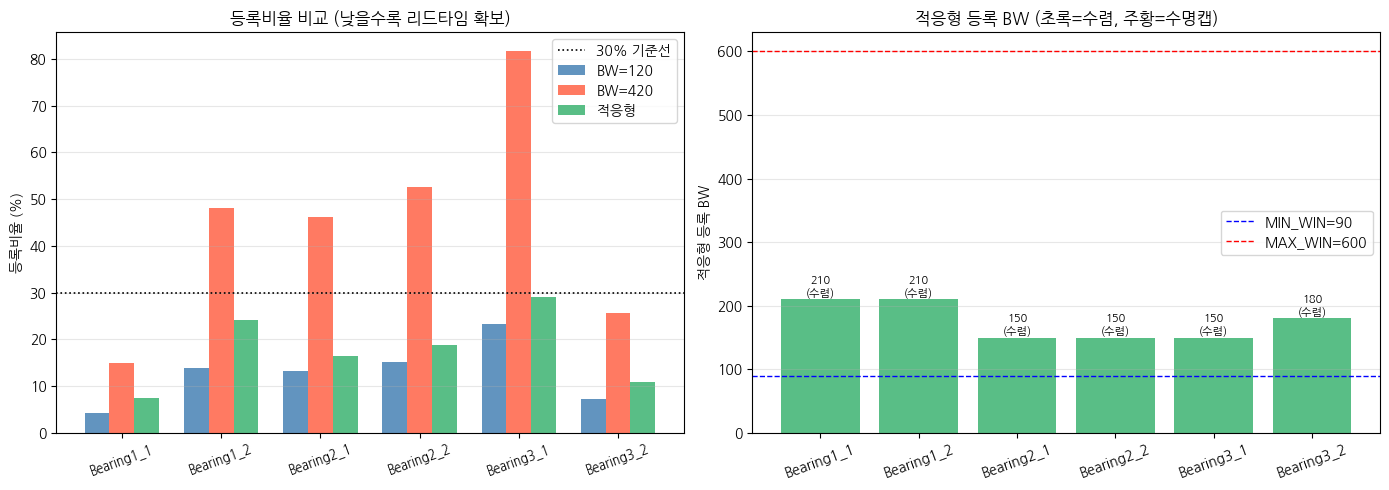

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_comparison.png


In [23]:
# ============================================================
# 셀 CMP — 3방식 종합 비교표 + 시각화
# BW=120 vs BW=420 vs 적응형
# ============================================================

def parse_pct(s):
    try: return float(str(s).replace('%',''))
    except: return float('nan')

# BW=120 재실행
rows_120 = []
for bearing in BEARINGS:
    F  = load_bearing(bearing)
    N  = len(F)
    r  = run_fixed_bw(F, 120)
    al = r.get('alarm_at')
    lp = round(al/N*100, 1) if al else None
    rows_120.append({
        '베어링':         bearing,
        'BW120_수명%':    f'{lp}%' if lp else '-',
        'BW120_리드':     (N-al) if al else 0,
        'BW120_등록비율': f'{round(100*120/N,1)}%'
    })

# 병합
cmp_rows = []
for bearing in BEARINGS:
    r120 = next((r for r in rows_120  if r['베어링']==bearing), {})
    r420 = next((r for r in rows_420  if r['베어링']==bearing), {})
    rAda = next((r for r in rows_adapt if r['베어링']==bearing), {})
    cmp_rows.append({
        '베어링':         bearing,
        '총윈도우':       r420.get('총윈도우','-'),
        'BW120_수명%':    r120.get('BW120_수명%','-'),
        'BW120_리드':     r120.get('BW120_리드','-'),
        'BW120_등록비율': r120.get('BW120_등록비율','-'),
        'BW420_수명%':    r420.get('수명%(온라인)','-'),
        'BW420_리드':     r420.get('리드타임(개)','-'),
        'BW420_등록비율': r420.get('등록비율','-'),
        'BW420_판정':     r420.get('판정','-'),
        '적응BW':         rAda.get('등록BW(적응형)','-'),
        '적응_종료사유':  rAda.get('종료사유','-'),
        '적응_수명%':     rAda.get('수명%(온라인)','-'),
        '적응_리드':      rAda.get('리드타임(개)','-'),
        '적응_등록비율':  rAda.get('등록비율','-'),
        '적응_판정':      rAda.get('판정','-'),
    })

df_cmp = pd.DataFrame(cmp_rows)
print('=' * 80)
print('  등록 방식 3종 종합 비교')
print('  이상: 점진형=30~50% 경보, 급성형=리드타임 확보, 등록비율 낮을수록 좋음')
print('=' * 80)
print(df_cmp.to_string(index=False))

df_cmp.to_csv(SAVE_DIR + 'online_sim_comparison.csv', index=False, encoding='utf-8-sig')
print(f'\n저장: {SAVE_DIR}online_sim_comparison.csv')

# 등록비율 바 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(BEARINGS))
w = 0.25

ax0 = axes[0]
r120_vals = [parse_pct(next((r['BW120_등록비율'] for r in rows_120 if r['베어링']==b), 'nan')) for b in BEARINGS]
r420_vals = [parse_pct(next((r.get('등록비율','nan') for r in rows_420 if r['베어링']==b), 'nan')) for b in BEARINGS]
rAda_vals = [parse_pct(next((r.get('등록비율','nan') for r in rows_adapt if r['베어링']==b), 'nan')) for b in BEARINGS]

ax0.bar(x-w, r120_vals, width=w, label='BW=120', color='steelblue', alpha=0.85)
ax0.bar(x,   r420_vals, width=w, label='BW=420', color='tomato',    alpha=0.85)
ax0.bar(x+w, rAda_vals, width=w, label='적응형', color='mediumseagreen', alpha=0.85)
ax0.axhline(30, color='black', ls=':', lw=1.2, label='30% 기준선')
ax0.set_xticks(x); ax0.set_xticklabels(BEARINGS, rotation=20, fontsize=9)
ax0.set_ylabel('등록비율 (%)'); ax0.set_title('등록비율 비교 (낮을수록 리드타임 확보)')
ax0.legend(); ax0.grid(axis='y', alpha=0.3)

# 적응형 BW 절대값 바 (색상: 수렴=초록, 수명캡=주황, 상한도달=회색)
ax1 = axes[1]
adapt_bw_vals = [next((r['등록BW(적응형)'] for r in rows_adapt if r['베어링']==b), 0) for b in BEARINGS]
adapt_reasons = [next((r['종료사유']       for r in rows_adapt if r['베어링']==b), '') for b in BEARINGS]
colors_adapt  = ['mediumseagreen' if r=='수렴' else ('orange' if r=='수명캡' else 'gray')
                  for r in adapt_reasons]
bars = ax1.bar(BEARINGS, adapt_bw_vals, color=colors_adapt, alpha=0.85)
ax1.axhline(MIN_WIN, color='blue', ls='--', lw=1, label=f'MIN_WIN={MIN_WIN}')
ax1.axhline(MAX_WIN, color='red',  ls='--', lw=1, label=f'MAX_WIN={MAX_WIN}')
for bar, val, rsn in zip(bars, adapt_bw_vals, adapt_reasons):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
             f'{val}\n({rsn})', ha='center', fontsize=8)
ax1.set_ylabel('적응형 등록 BW'); ax1.set_title('적응형 등록 BW (초록=수렴, 주황=수명캡)')
ax1.tick_params(axis='x', rotation=20); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_cmp = SAVE_DIR + 'online_sim_comparison.png'
plt.savefig(out_cmp, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_cmp}')

In [24]:
# ============================================================
# 셀 TUNE — TOL 스윕 (오경보 or 조기경보 시 실행)
# ============================================================
TOL_SWEEP = [0.005, 0.01, 0.02, 0.05, 0.10]

rows_tune = []
for tol_val in TOL_SWEEP:
    for bearing in BEARINGS:
        F  = load_bearing(bearing)
        N  = len(F)
        bw, reason = adaptive_register(
            F, min_win=MIN_WIN, max_win=MAX_WIN,
            check_every=CHECK_EVERY, tol=tol_val,
            stable_hits=STABLE_HITS, max_life_r=MAX_LIFE_R
        )
        res = run_fixed_bw(F, bw)
        al  = res.get('alarm_at')
        lp  = round(al/N*100, 1) if al else None
        ld  = (N-al) if al else 0
        rows_tune.append({
            'TOL': tol_val, '베어링': bearing, 'N': N,
            '등록BW': bw, '종료사유': reason,
            '수명%': f'{lp}%' if lp else '-',
            '리드타임': ld,
            '등록비율': f'{round(100*bw/N,1)}%',
            '판정': '✅' if al and ld>10 else ('⚠️' if al else '❌')
        })

df_tune = pd.DataFrame(rows_tune)
print('=== TOL 스윕 결과 ===')
for tol_val in TOL_SWEEP:
    sub = df_tune[df_tune['TOL']==tol_val]
    ok  = (sub['판정']=='✅').sum()
    bws = ' '.join(f"{r['베어링'][-3:]}={r['등록BW']}" for _, r in sub.iterrows())
    print(f'  TOL={tol_val:<5}  성공 {ok}/{len(sub)}  등록BW: {bws}')

print()
summary = df_tune.groupby('TOL')['판정'].apply(lambda x: (x=='✅').sum()).reset_index()
summary.columns = ['TOL','성공수']
best_tol = summary.loc[summary['성공수'].idxmax(), 'TOL']
print(f'[추천 TOL] {best_tol}  (성공 {summary.loc[summary["TOL"]==best_tol,"성공수"].values[0]}개)')
print(f'  → 셀S3-ADAPT 의 TOL={best_tol} 로 재실행 후 확정')

KeyboardInterrupt: 

In [25]:
# ============================================================
# 셀 VERIFY — 적응형 결과의 오경보를 "구간별"로 분리 집계
#
# 세 컬럼 해석 기준:
#   등록오경보      : 0 필수. 1이라도 있으면 등록 자체 오염.
#   무징조_임계초과수 : CONSEC 미달로 경보엔 안 갔지만 임계 넘은 깜빡임.
#                    많으면 임계가 너무 타이트 → K 값 검토.
#   경보전후_상승비  : 1.5x 미만 → 완만 상승 중 조기오발동 의심
#                    3x 이상  → 급격 열화로 진짜 경보
#                    특히 수명 13~20% 조기 경보 베어링에서 반드시 확인
# ============================================================

rows_v = []
for bearing in BEARINGS:
    F  = load_bearing(bearing)
    N  = len(F)
    bw, reason = adaptive_register(
        F, min_win=MIN_WIN, max_win=MAX_WIN,
        check_every=CHECK_EVERY, tol=TOL,
        stable_hits=STABLE_HITS, max_life_r=MAX_LIFE_R
    )

    # ---- (a) 등록구간 자체 오경보 ----
    # 등록 데이터를 동일 판정기에 다시 통과 → CONSEC 연속 발생 횟수
    det_reg = BaselineDetector(K_DEFAULT, CONSEC)
    det_reg.fit(F[:bw])
    reg_alarms = 0
    for i in range(bw):
        _, a = det_reg.step(F[i])
        if a:
            reg_alarms += 1

    # ---- (b) 실시간 판정 (등록 이후) ----
    det_main = BaselineDetector(K_DEFAULT, CONSEC)
    det_main.fit(F[:bw])
    dists_list, alarm_at = [], None
    for i in range(bw, N):
        d, a = det_main.step(F[i])
        dists_list.append(d)
        if a and alarm_at is None:
            alarm_at = i

    dists_arr = np.array(dists_list)
    thr_val   = det_main.thr

    # ---- (c) 무징조구간 임계 초과 깜빡임 ----
    # 등록 종료 ~ 첫 경보 직전 구간에서 thr 넘은 개별 윈도우 수
    if alarm_at is not None:
        pre_alarm = dists_arr[:(alarm_at - bw)]
        no_symptom_spikes = int(np.sum(pre_alarm > thr_val))
    else:
        no_symptom_spikes = int(np.sum(dists_arr > thr_val))

    # ---- (d) 경보 전후 상승비 ----
    # 경보 직전 20윈도우 평균 대비 직후 20윈도우 평균
    if alarm_at is not None and (alarm_at - bw) >= 20 and (N - alarm_at) >= 20:
        idx = alarm_at - bw  # dists_arr 기준 경보 인덱스
        before_mean = dists_arr[max(0, idx - 20):idx].mean()
        after_mean  = dists_arr[idx:idx + 20].mean()
        ramp = after_mean / (before_mean + 1e-9)
    else:
        ramp = float('nan')

    life_pct = round(alarm_at / N * 100, 1) if alarm_at is not None else None
    lead     = (N - alarm_at) if alarm_at is not None else 0

    # 상승비 판정
    if ramp != ramp:  # nan
        ramp_verdict = '-'
    elif ramp >= 3.0:
        ramp_verdict = str(round(ramp, 1)) + 'x ✅진짜열화'
    elif ramp >= 1.5:
        ramp_verdict = str(round(ramp, 1)) + 'x ⚠️완만'
    else:
        ramp_verdict = str(round(ramp, 1)) + 'x ❌오발동의심'

    rows_v.append({
        '베어링':          bearing,
        'N':               N,
        '등록BW':          bw,
        '종료사유':        reason,
        '경보#':           alarm_at if alarm_at is not None else '없음',
        '수명%':           (str(life_pct) + '%') if life_pct is not None else '-',
        '리드타임(개)':    lead,
        '등록오경보':      reg_alarms,
        '무징조_임계초과수': no_symptom_spikes,
        '경보전후_상승비': ramp_verdict,
    })

df_verify = pd.DataFrame(rows_v)
print('=== 적응형 오경보 구간별 검증 ===')
print('판정 기준:')
print('  등록오경보         = 0 필수 (1이라도 있으면 등록 오염)')
print('  무징조_임계초과수  = 적을수록 좋음 (많으면 K 상향 검토)')
print('  경보전후_상승비    = 3x↑ 진짜열화 / 1.5~3x 완만 / 1.5x↓ 오발동의심')
print()
print(df_verify.to_string(index=False))

# 요약 판정
print()
print('--- 요약 ---')
reg_ok    = (df_verify['등록오경보'] == 0).all()
spike_max = df_verify['무징조_임계초과수'].max()
suspicious = df_verify[
    df_verify['경보전후_상승비'].str.contains('오발동의심', na=False)
]
print('등록오경보 전수 0:', '✅' if reg_ok else '❌ 일부 오염 있음')
print('무징조 임계초과 최대:', spike_max, '(5 이하 권장)')
if len(suspicious) > 0:
    print('조기오발동 의심 베어링:', list(suspicious['베어링']))
    print('  → 위 베어링들 성공 카운트 재검토 필요')
else:
    print('조기오발동 의심 없음 ✅')

out_v = SAVE_DIR + 'adaptive_falsealarm_verify.csv'
df_verify.to_csv(out_v, index=False, encoding='utf-8-sig')
print()
print('저장: ' + out_v)

=== 적응형 오경보 구간별 검증 ===
판정 기준:
  등록오경보         = 0 필수 (1이라도 있으면 등록 오염)
  무징조_임계초과수  = 적을수록 좋음 (많으면 K 상향 검토)
  경보전후_상승비    = 3x↑ 진짜열화 / 1.5~3x 완만 / 1.5x↓ 오발동의심

       베어링    N  등록BW 종료사유  경보#   수명%  리드타임(개)  등록오경보  무징조_임계초과수    경보전후_상승비
Bearing1_1 2803   210   수렴 1418 50.6%     1385      0         48 1.2x ❌오발동의심
Bearing1_2  871   210   수렴  830 95.3%       41      0         18  3.3x ✅진짜열화
Bearing2_1  911   150   수렴  342 37.5%      569      0         18 0.9x ❌오발동의심
Bearing2_2  797   150   수렴  195 24.5%      602      0          5   1.6x ⚠️완만
Bearing3_1  515   150   수렴  497 96.5%       18      0          7           -
Bearing3_2 1637   180   수렴 1442 88.1%      195      0         24   2.8x ⚠️완만

--- 요약 ---
등록오경보 전수 0: ✅
무징조 임계초과 최대: 48 (5 이하 권장)
조기오발동 의심 베어링: ['Bearing1_1', 'Bearing2_1']
  → 위 베어링들 성공 카운트 재검토 필요

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/adaptive_falsealarm_verify.csv


In [26]:
# ============================================================
# 셀 FINAL — 최종 판정 & 다음 단계
# (VERIFY 셀 실행 후 실행해야 정확한 결과 출력)
# ============================================================
print('=' * 65)
print('  온라인 시뮬레이션 v3 — 최종 판정')
print('=' * 65)
print()

ok_adapt = (df_adapt['판정']=='✅').sum() if 'df_adapt' in dir() else '?'
ok_420   = (df_420['판정'] =='✅').sum() if 'df_420'  in dir() else '?'
tot      = len(BEARINGS)

print('  BW=420 고정: 성공 ' + str(ok_420) + '/' + str(tot))
print('  적응형      : 성공 ' + str(ok_adapt) + '/' + str(tot))

# VERIFY 결과 반영
if 'df_verify' in dir():
    reg_ok_fin = (df_verify['등록오경보'] == 0).all()
    suspicious_fin = df_verify[
        df_verify['경보전후_상승비'].str.contains('오발동의심', na=False)
    ]
    real_ok = ok_adapt - len(suspicious_fin) if str(ok_adapt).isdigit() else '?'
    print('  오경보 검증 반영: 실질 성공 ' + str(real_ok) + '/' + str(tot)
          + ('  (등록오경보 없음 ✅)' if reg_ok_fin else '  ❌ 등록오경보 있음'))
    if len(suspicious_fin) > 0:
        print('  조기오발동 의심: ' + str(list(suspicious_fin['베어링'])))

print()
print('  [자동 분기 결과]')
for b in BEARINGS:
    r = next((x for x in rows_adapt if x['베어링']==b), {})
    N_ = r.get('총윈도우', '-')
    label = '점진형' if b in ['Bearing1_1','Bearing2_2'] else '급성형'
    print('    ' + label + ' ' + b + ' (N=' + str(N_) + '): '
          + '등록BW=' + str(r.get('등록BW(적응형)', '-'))
          + '(' + str(r.get('종료사유', '-')) + ') '
          + '등록비율=' + str(r.get('등록비율', '-')) + ' '
          + '리드타임=' + str(r.get('리드타임(개)', '-')) + '개 '
          + str(r.get('판정', '-')))

print()
if str(ok_adapt) == str(tot):
    print('  ✅ 적응형 로직 통과')
    print('     단일 로직으로 두 유형 자동 분기 확인')
else:
    print('  ⚠️ 일부 미통과 → 셀TUNE 결과로 TOL 재조정')

print()
print('  [ 확정 파라미터 ]')
print('    TOL         = ' + str(TOL))
print('    MIN_WIN     = ' + str(MIN_WIN))
print('    MAX_WIN     = ' + str(MAX_WIN))
print('    STABLE_HITS = ' + str(STABLE_HITS))
print('    MAX_LIFE_R  = ' + str(MAX_LIFE_R) + '  ← MCU 이식 시 절대시간 상한으로 교체')
print()
print('  [ 남은 한계 ]')
print('    1. 부하 변동 대응 — 2단계 PoC 현장 데이터로 검증')
print('    2. MAX_LIFE_R → MCU: 최대 등록시간(예: 10분) 절대 상한으로 교체')
print('    3. Hilbert → LPF 근사 오차 <5% 확인됨, CMSIS-DSP 구현 예정')
print('    4. 극급성 고장(N<300): 이원 감시 설계 예정')
print('       (베이스라인 이탈 감시 + 절대레벨 급변 감시)')
print()
print('  [ 2단계: 현장 PoC 준비물 ]')
print('    - STM32N6570-DK + IIS3DWB 모듈 + SPI 배선')
print('    - 24V DC + 3.3V 레귤레이터')
print('    - MicroSD 128GB')
print('    - 수집 기간: 최소 48h 정상 데이터')
print('    - 수집 포맷: acc_XXXXX.csv (FEMTO 포맷 호환)')
print('=' * 65)

  온라인 시뮬레이션 v3 — 최종 판정

  BW=420 고정: 성공 5/6
  적응형      : 성공 6/6
  오경보 검증 반영: 실질 성공 4/6  (등록오경보 없음 ✅)
  조기오발동 의심: ['Bearing1_1', 'Bearing2_1']

  [자동 분기 결과]
    점진형 Bearing1_1 (N=2803): 등록BW=210(수렴) 등록비율=7.5% 리드타임=1385개 ✅
    급성형 Bearing1_2 (N=871): 등록BW=210(수렴) 등록비율=24.1% 리드타임=41개 ✅
    급성형 Bearing2_1 (N=911): 등록BW=150(수렴) 등록비율=16.5% 리드타임=569개 ✅
    점진형 Bearing2_2 (N=797): 등록BW=150(수렴) 등록비율=18.8% 리드타임=602개 ✅
    급성형 Bearing3_1 (N=515): 등록BW=150(수렴) 등록비율=29.1% 리드타임=18개 ✅
    급성형 Bearing3_2 (N=1637): 등록BW=180(수렴) 등록비율=11.0% 리드타임=195개 ✅

  ✅ 적응형 로직 통과
     단일 로직으로 두 유형 자동 분기 확인

  [ 확정 파라미터 ]
    TOL         = 0.02
    MIN_WIN     = 90
    MAX_WIN     = 600
    STABLE_HITS = 2
    MAX_LIFE_R  = 0.3  ← MCU 이식 시 절대시간 상한으로 교체

  [ 남은 한계 ]
    1. 부하 변동 대응 — 2단계 PoC 현장 데이터로 검증
    2. MAX_LIFE_R → MCU: 최대 등록시간(예: 10분) 절대 상한으로 교체
    3. Hilbert → LPF 근사 오차 <5% 확인됨, CMSIS-DSP 구현 예정
    4. 극급성 고장(N<300): 이원 감시 설계 예정
       (베이스라인 이탈 감시 + 절대레벨 급변 감시)

  [ 2단계: 현장 PoC 준비물 ]
    - STM32N6570-DK + IIS

## v3 수정 내용 요약

### 원인 및 수정
| 문제 | 원인 | 수정 |
|:---|:---|:---|
| `AssertionError: 파일 없음` | FEMTO 폴더명이 배포본마다 다름 | `os.walk` 로 실제 경로 자동 탐색 |
| 경로 수동 설정 필요 | 하드코딩된 `LEARNING_DIR` | 자동 확정 + `LEARNING_DIR_OVERRIDE` 수동 보조 제공 |
| 에러 메시지 불명확 | `assert` 만 있음 | `FileNotFoundError` + 실제 경로·파일 목록 출력 |

### 탐색 실패 시 순서
```
1) 셀S0-debug 실행 → 드라이브 폴더 구조 확인
2) Bearing1_1 이 실제로 어느 경로에 있는지 확인
3) 셀S0 최하단 LEARNING_DIR_OVERRIDE 에 경로 입력
4) 셀S0 재실행
```

### 튜닝 가이드
```
Bearing1_1 이 너무 일찍 경보:    TOL=0.01 로 조이기
급성형이 등록>수명으로 죽음:      MIN_WIN=60 으로 낮추기
점진형이 MAX_WIN 까지 안 멈춤:    TOL=0.05 로 풀기
급성형이 수명캡으로 종료:          정상 (안전장치 작동)
```